In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import plotly.express as px

In [2]:
!pip install pandas numpy scikit-learn umap-learn hdbscan matplotlib seaborn statsmodels plotly 

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Save metadata
# --- Step 1: Load original file ---
expr2 = pd.read_csv(
    "Nina_Final_Merged_Dataset_Human_Protein_Expression.tsv",
    sep="\t"
)
expr2 = expr2.set_index("Protein_ID")
expr2

/tmp/ipykernel_3398692/3093314183.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  expr2 = pd.read_csv(


,Gene,B67_1_Rep1_Peptides,B67_1_Rep2_Peptides,B67_1_Rep3_Peptides,CRC0_2_Rep1_Peptides,CRC0_2_Rep2_Peptides,CRC0_2_Rep3_Peptides,CRC4_P1_Rep1_Peptides,CRC4_P1_Rep2_Peptides,CRC4_P1_Rep3_Peptides,...,VCU_91_Rep3_Intensity,VCU_97_Rep1_Intensity,VCU_97_Rep2_Intensity,VCU_97_Rep3_Intensity,VCU_98_Rep1_Intensity,VCU_98_Rep2_Intensity,VCU_98_Rep3_Intensity,VCU_99_Rep1_Intensity,VCU_99_Rep2_Intensity,VCU_99_Rep3_Intensity
Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,GYG1,27.0,24.0,21.0,24.0,27.0,27.0,9.0,12.0,9.0,...,41912.0,15771.0,15525.0,17162.0,20331.0,20819.0,19485.0,18613.0,22225.0,22910.0
AL1L2,ALDH1L2,57.0,54.0,54.0,6.0,15.0,9.0,6.0,6.0,NaN,...,1494.0,5393.0,175.0,182.0,NaN,1822.0,1760.0,872.0,871.0,1047.0
FUBP3,FUBP3,84.0,78.0,69.0,84.0,81.0,87.0,60.0,57.0,57.0,...,160959.0,55033.0,48185.0,53813.0,173536.0,167175.0,175511.0,189312.0,189670.0,193377.0
SNX12,SNX12,30.0,30.0,33.0,33.0,36.0,36.0,30.0,24.0,27.0,...,41390.0,38405.0,38231.0,42265.0,48973.0,49372.0,47552.0,46582.0,46151.0,48000.0
ARGAL,ARHGEF10L,84.0,72.0,78.0,93.0,90.0,102.0,57.0,60.0,60.0,...,26415.0,3290.0,3690.0,2894.0,26502.0,26217.0,29154.0,31441.0,31001.0,29012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PCDG6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FBLN7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL1B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,989.0,967.0,1162.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
metadata = pd.read_csv(
    "Human_Proteome_UP000005640_251107_Genes.tsv",
    sep="\t"
)
metadata = metadata.set_index("Protein_ID")
metadata

,Gene
Protein_ID,
CP2D7,CYP2D7
PIOS1,PIGBOS1
MOTSC,MT-RNR1
CD3CH,CD300H
NBDY,NBDY
...,...
YP002,PRO0461
YT001,PRO0628
YE014,PRO0255


In [5]:
import pandas as pd

# Load tab-delimited file from current working directory
df_md = pd.read_csv("metadata.tsv", sep="\t")

# Peek at shape and first few rows
print("Shape:", df_md.shape)
print(df_md)

Shape: (177, 4)
                        Column_Name Sample_ID Replicate    Type
0     B67_1_Rep1_CorrectedIntensity     B67_1      Rep1  Breast
1     B67_1_Rep2_CorrectedIntensity     B67_1      Rep2  Breast
2     B67_1_Rep3_CorrectedIntensity     B67_1      Rep3  Breast
3    CRC0_2_Rep1_CorrectedIntensity    CRC0_2      Rep1   Colon
4    CRC0_2_Rep2_CorrectedIntensity    CRC0_2      Rep2   Colon
..                              ...       ...       ...     ...
172  VCU_98_Rep2_CorrectedIntensity    VCU_98      Rep2   Colon
173  VCU_98_Rep3_CorrectedIntensity    VCU_98      Rep3   Colon
174  VCU_99_Rep1_CorrectedIntensity    VCU_99      Rep1   Colon
175  VCU_99_Rep2_CorrectedIntensity    VCU_99      Rep2   Colon
176  VCU_99_Rep3_CorrectedIntensity    VCU_99      Rep3   Colon

[177 rows x 4 columns]


In [6]:
import pandas as pd

# expr2: the merged expression dataframe
# df_md: your metadata dataframe

# Step 1: Get all columns that correspond to Peptides
peptide_cols = [c for c in expr2.columns if c.endswith('_Peptides')]

# Step 2: Extract Sample_IDs before "_Rep"
expr_sample_ids = [c.split('_Rep')[0] for c in peptide_cols]

# Step 3: Remove duplicates (since multiple replicates)
expr_sample_ids = list(set(expr_sample_ids))

# Step 4: Get Sample_IDs already present in df_md
md_sample_ids = df_md['Sample_ID'].unique().tolist()

# Step 5: Identify Sample_IDs in expr2 not in df_md
missing_sample_ids = [s for s in expr_sample_ids if s not in md_sample_ids]

print("Sample_IDs in expr2 not in metadata:")
print(missing_sample_ids)



Sample_IDs in expr2 not in metadata:
['VCU_52', 'G133_P3']


In [7]:
import pandas as pd

# expr2: merged expression dataframe
# df_md: original metadata dataframe for type mapping

# Optional: dictionary for new sample types
# Example: {'VCU_52': 'Breast', 'VCU_99': 'Colon'}
new_sample_types = {'VCU_52': 'Breast', 'G133_P3' : 'Pancreatic'}

# Step 1: Identify all _Intensity columns
intensity_cols = [c for c in expr2.columns if c.endswith('_Intensity')]

# Step 2: Extract Sample_ID and Replicate from column names
sample_ids = [c.split('_Rep')[0] for c in intensity_cols]
replicates = ['Rep'+c.split('_Rep')[1].split('_')[0] for c in intensity_cols]

# Step 3: Build type mapping
type_map = df_md.set_index('Sample_ID')['Type'].to_dict()

# Assign type for each sample; use new_sample_types if not in df_md
types = []
for sid in sample_ids:
    if sid in type_map:
        types.append(type_map[sid])
    elif sid in new_sample_types:
        types.append(new_sample_types[sid])
    else:
        types.append('Unknown')  # fallback if type is missing

# Step 4: Build new metadata DataFrame
df_new_md = pd.DataFrame({
    'Column_Name': intensity_cols,
    'Sample_ID': sample_ids,
    'Replicate': replicates,
    'Type': types
})

# Optional: sort by Sample_ID then Replicate
df_new_md = df_new_md.sort_values(['Sample_ID', 'Replicate']).reset_index(drop=True)

# Step 5: Save new metadata table
df_new_md.to_csv('metadata_updated.tsv', sep='\t', index=False)

print(f"[INFO] New metadata table created with {len(df_new_md)} columns.")
print(df_new_md.head())


[INFO] New metadata table created with 183 columns.
             Column_Name Sample_ID Replicate    Type
0   B67_1_Rep1_Intensity     B67_1      Rep1  Breast
1   B67_1_Rep2_Intensity     B67_1      Rep2  Breast
2   B67_1_Rep3_Intensity     B67_1      Rep3  Breast
3  CRC0_2_Rep1_Intensity    CRC0_2      Rep1   Colon
4  CRC0_2_Rep2_Intensity    CRC0_2      Rep2   Colon


In [14]:
import pandas as pd
import numpy as np

# --- Step 1: Select only columns ending with '.raw.PG.Quantity' ---
sample_cols = [col for col in expr2.columns if col.endswith('_Intensity')]

# --- Step 2: Drop rows with max < 2 in NrOfStrippedSequencesIdentified columns ---
nr_cols = [c for c in expr2.columns if c.endswith('_Peptides')]
expr_filtered = expr2[expr2[nr_cols].max(axis=1) >= 2]

# --- Step 3: Max Sum Normalization (Intra-sample normalization) ---
# Select only expression columns
quantity_cols = [col for col in expr_quant.columns if col.endswith("_Intensity")]

# Compute total intensity per sample
total_intensity = expr_norm[quantity_cols].sum(axis=0)

# Identify maximum total intensity across samples
max_total = total_intensity.max()

# Apply MaxSum normalization
# Each value divided by its sample total, multiplied by maximum total
expr_norm[quantity_cols] = expr_norm[quantity_cols].div(total_intensity, axis=1) * max_total

# --- Step 4: Propagate NaNs across replicates if more than 1 missing per cell line ---
quantity_cols = [c for c in expr_filtered.columns if c.endswith('_Intensity')]
expr_quant = expr_filtered[quantity_cols].copy()

for cell_line, group in df_new_md.groupby("Sample_ID"):
    cols = group["Column_Name"].tolist()  # columns corresponding to this cell line
    # If more than 1 missing per row for this cell line, set all to NaN
    mask = (expr_quant[cols].isna().sum(axis=1) > 1)
    expr_quant.loc[mask, cols] = np.nan

# --- Step 5: Impute missing values using the average of the other two replicates ---
for sample_id, group in df_new_md.groupby("Sample_ID"):
    cols = group["Column_Name"].tolist()

    # For rows where exactly ONE replicate is missing
    one_missing_mask = (expr_quant[cols].isna().sum(axis=1) == 1)

    # Subset the rows needing imputation
    rows_to_fix = expr_quant.loc[one_missing_mask, cols]

    # Fill missing value = mean of non-missing replicates
    expr_quant.loc[one_missing_mask, cols] = rows_to_fix.apply(
        lambda row: row.fillna(row.mean()), axis=1
    )

# --- Step 6: Merge in Gene information ---
expr_quant2 = metadata.merge(
    expr_quant,
    left_index=True,
    right_index=True,
    how="left"
)
expr_quant2.to_csv("Nina_AllProteins_MaxSum_RepAvgImpute_120325.tsv", sep="\t")
expr_quant2

,Gene,B67_1_Rep1_Intensity,B67_1_Rep2_Intensity,B67_1_Rep3_Intensity,CRC0_2_Rep1_Intensity,CRC0_2_Rep2_Intensity,CRC0_2_Rep3_Intensity,CRC4_P1_Rep1_Intensity,CRC4_P1_Rep2_Intensity,CRC4_P1_Rep3_Intensity,...,VCU_91_Rep3_Intensity,VCU_97_Rep1_Intensity,VCU_97_Rep2_Intensity,VCU_97_Rep3_Intensity,VCU_98_Rep1_Intensity,VCU_98_Rep2_Intensity,VCU_98_Rep3_Intensity,VCU_99_Rep1_Intensity,VCU_99_Rep2_Intensity,VCU_99_Rep3_Intensity
Protein_ID,,,,,,,,,,,,,,,,,,,,,
CP2D7,CYP2D7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PIOS1,PIGBOS1,321.0,230.0,139.0,256.5,361.0,152.0,87.0,130.0,173.0,...,345.0,158.0,225.0,91.0,340.0,243.0,219.0,NaN,NaN,NaN
MOTSC,MT-RNR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD3CH,CD300H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NBDY,NBDY,1988.0,1064.0,796.0,7266.0,6850.0,7353.0,554.0,443.0,332.0,...,7572.0,9005.0,7309.0,7473.0,6248.0,7873.0,4941.0,6456.0,8774.0,8163.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP002,PRO0461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YT001,PRO0628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE014,PRO0255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Copy original data
expr_norm = expr_quant2.copy()

# Step 4: Log2 transformation
expr_norm[quantity_cols] = np.log2(expr_norm[quantity_cols] + 1)
expr_norm.to_csv("Nina_AllProteins_MaxSum_RepAvgImpute_Log2_120325.tsv", sep="\t")
expr_norm

,Gene,B67_1_Rep1_Intensity,B67_1_Rep2_Intensity,B67_1_Rep3_Intensity,CRC0_2_Rep1_Intensity,CRC0_2_Rep2_Intensity,CRC0_2_Rep3_Intensity,CRC4_P1_Rep1_Intensity,CRC4_P1_Rep2_Intensity,CRC4_P1_Rep3_Intensity,...,VCU_91_Rep3_Intensity,VCU_97_Rep1_Intensity,VCU_97_Rep2_Intensity,VCU_97_Rep3_Intensity,VCU_98_Rep1_Intensity,VCU_98_Rep2_Intensity,VCU_98_Rep3_Intensity,VCU_99_Rep1_Intensity,VCU_99_Rep2_Intensity,VCU_99_Rep3_Intensity
Protein_ID,,,,,,,,,,,,,,,,,,,,,
CP2D7,CYP2D7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PIOS1,PIGBOS1,8.330917,7.851749,7.129283,8.008429,8.499846,7.257388,6.459432,7.033423,7.442943,...,8.434628,7.312883,7.820179,6.523562,8.413628,7.930737,7.781360,NaN,NaN,NaN
MOTSC,MT-RNR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD3CH,CD300H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NBDY,NBDY,10.957828,10.056638,9.638436,12.827144,12.742099,12.844313,9.116344,8.794416,8.379378,...,12.886649,13.136671,12.835656,12.867665,12.609410,12.942881,12.270879,12.656648,13.099183,12.99506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP002,PRO0461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YT001,PRO0628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE014,PRO0255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
import pandas as pd

# 1️⃣ Example setup (you already have these)
# metadata_filtered = pd.DataFrame(...)
# expr_filtered = pd.DataFrame(...)
expr_norm2 = expr_norm.drop(columns="Gene")
# 2️⃣ Create a mapping from each column in expr_filtered to its Sample_ID
col_to_sample = df_new_md.set_index('Column_Name')['Sample_ID'].to_dict()

# 3️⃣ Rename expr_filtered columns using the Sample_ID mapping
expr_renamed = expr_norm2.rename(columns=col_to_sample)

# 4️⃣ Group columns by Sample_ID and average replicates
expr_avg = expr_renamed.groupby(level=0, axis=1).mean()

expr_avg1 = metadata.merge(
    expr_avg,
    left_index=True,
    right_index=True,
    how="left"
)
# ✅ Result: expr_avg now has one column per Sample_ID, with average expression across replicates

expr_avg1.to_csv("Nina_AllProteins_MaxSum_RepAvgImpute_Log2_RepAveraged_120325.tsv", sep="\t")
expr_avg1

/tmp/ipykernel_3398692/3650546533.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  expr_avg = expr_renamed.groupby(level=0, axis=1).mean()


,Gene,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H30_2,...,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_87,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
CP2D7,CYP2D7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PIOS1,PIGBOS1,7.770650,7.921887,6.978599,NaN,7.951343,NaN,6.437769,8.637413,7.844989,...,8.601549,8.377503,7.838454,8.291094,NaN,9.357620,8.542350,7.218875,8.041908,NaN
MOTSC,MT-RNR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD3CH,CD300H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NBDY,NBDY,10.217634,12.804519,8.763379,11.753558,12.930991,11.474914,9.475073,12.209896,12.572519,...,11.746567,12.714610,11.296806,12.800551,11.194249,14.688804,12.723436,12.946664,12.607723,12.916964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP002,PRO0461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YT001,PRO0628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE014,PRO0255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Merge expression values across replicates #
expr_quant3 = expr_quant2.drop(columns="Gene")
col_to_sample = df_new_md.set_index('Column_Name')['Sample_ID'].to_dict()
expr_renamed = expr_quant3.rename(columns=col_to_sample)
expr_avg = expr_renamed.groupby(level=0, axis=1).mean()
expr_avg3 = metadata.merge(
    expr_avg,
    left_index=True,
    right_index=True,
    how="left"
)
expr_avg3.to_csv("Nina_AllProteins_MaxSum_RepAvgImpute_RepAveraged_120325.tsv", sep="\t")
expr_avg3


/tmp/ipykernel_3398692/2177299201.py:5: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  expr_avg = expr_renamed.groupby(level=0, axis=1).mean()


,Gene,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H30_2,...,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_87,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
CP2D7,CYP2D7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PIOS1,PIGBOS1,230.000000,256.500000,130.0,NaN,249.0,NaN,86.000000,410.666667,251.333333,...,400.000000,333.666667,231.000000,344.000000,NaN,656.000000,372.500000,158.0,267.333333,NaN
MOTSC,MT-RNR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD3CH,CD300H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NBDY,NBDY,1282.666667,7156.333333,443.0,3466.333333,7814.0,2857.0,767.666667,4739.666667,6106.666667,...,3600.333333,6841.333333,2543.666667,7179.333333,2542.333333,26484.333333,6905.333333,7929.0,6354.000000,7797.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YP002,PRO0461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YT001,PRO0628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE014,PRO0255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Create a simplified metadata table for PCA
df_pca_md = df_new_md[['Sample_ID', 'Type']].drop_duplicates().reset_index(drop=True)
df_pca_md

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
...,...,...
56,VCU_87,Gallbladder
57,VCU_91,Pancreatic
58,VCU_97,Lung
59,VCU_98,Colon


In [33]:
# --- Step 3: Drop rows with ANY missing values ---
expr_avg_noNA = expr_avg1[expr_avg1.isna().sum(axis=1) == 0]
expr_avg_noNA

,Gene,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H30_2,...,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_87,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
UBA6,UBA6,15.328913,16.652079,15.585790,16.530554,17.994656,16.109197,16.395952,17.524945,16.235948,...,17.388412,17.183264,16.881685,17.232664,16.324081,18.227691,17.567927,17.848873,17.242234,17.522511
ESYT2,ESYT2,14.536260,14.100621,13.382707,13.360824,16.041524,13.870416,12.970300,14.935475,16.062480,...,15.836865,15.533469,15.305033,15.730956,14.820604,14.440241,15.048929,13.988184,15.343177,15.352337
BLT3B,BLTP3B,10.371815,12.861769,8.304255,9.773264,13.662030,11.185762,9.673950,12.578296,11.306134,...,10.381483,12.071486,12.276186,11.513950,12.402698,12.978925,11.221149,12.034151,11.573213,12.016078
SHOT1,SHTN1,11.562930,12.436341,11.199949,11.474999,14.564943,11.995953,10.629103,12.960755,13.434572,...,11.979409,12.554743,12.052960,10.997221,11.806186,14.276294,13.494553,10.872854,13.493862,12.937465
HACL2,ILVBL,13.734120,14.756771,14.174855,13.643529,14.899253,14.606481,12.375437,14.725772,15.711804,...,14.499935,15.632122,15.267077,15.591191,14.795717,13.998600,15.133712,11.446072,13.812744,15.116516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISOC1,ISOC1,13.722828,16.020169,14.326006,14.426515,16.707490,15.607831,14.635596,16.009428,14.526373,...,15.195410,16.541336,16.078558,14.426204,16.133305,16.537474,16.379140,13.967454,16.690102,16.121241
IFG15,TOR1AIP2,13.751347,15.231218,13.576145,13.561182,14.965120,14.231591,13.592718,14.964734,15.279527,...,14.162080,15.153421,14.600544,14.721188,14.478956,15.338931,15.622691,13.956622,15.215088,15.314656
ABRAL,ABRACL,11.644731,12.873873,13.059701,11.673027,14.124477,12.722338,12.985758,14.528277,12.359990,...,12.643563,12.412801,12.698187,12.626160,13.357021,13.656395,13.069825,13.024110,13.304412,13.903237


In [23]:
#NOT USED #
from sklearn.impute import KNNImputer
# --- Step 3: Drop rows with >50% NaN in quantity columns ---
threshold = 0.5
expr_avg_filtered = expr_avg[expr_avg.isna().mean(axis=1) <= threshold]

# --- Step 4: KNN Imputation using 2 nearest neighbors ---
imputer = KNNImputer(n_neighbors=2, weights="uniform")
expr_imputed = imputer.fit_transform(expr_avg_filtered)
expr_imputed = pd.DataFrame(expr_imputed, columns=expr_avg_filtered.columns, index=expr_avg_filtered.index)

expr_imputed

,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H30_2,H32_2,...,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_87,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,13.100614,12.767979,9.576825,11.517666,15.878984,12.166197,11.380638,14.484237,10.193304,14.462005,...,14.892686,14.184852,14.208043,14.212177,12.992347,13.934935,15.305525,13.978164,14.302432,14.369271
AL1L2,15.434430,8.806588,6.711329,10.518196,8.950256,9.821050,9.472272,10.714812,9.295423,11.386721,...,8.952948,7.999121,8.318494,8.154826,7.601264,10.642508,9.154791,9.124090,10.807211,9.857148
FUBP3,15.008943,16.100970,14.789386,15.256552,16.741519,15.684443,14.407466,17.204201,16.782857,17.032323,...,15.728807,16.748408,16.568594,16.094533,15.394505,17.531916,17.317162,15.673352,17.392367,17.541539
SNX12,14.460709,15.553588,13.926841,14.423072,15.718494,15.126856,14.468432,16.090790,14.815700,14.890829,...,14.957280,15.611811,15.544195,15.434406,14.449517,15.581943,15.397135,15.272916,15.569471,15.517466
ARGAL,13.464356,14.466067,13.234155,11.579878,14.457401,12.690587,10.394020,15.528595,13.415028,16.060334,...,13.337651,13.895672,14.966732,12.614930,13.041087,13.843868,14.832403,11.677818,14.734531,14.894964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BUB1,7.077453,7.912519,6.546514,6.493180,8.286172,6.297654,8.361454,6.812148,9.178800,8.774577,...,10.229270,8.466753,8.240495,8.089748,8.354674,9.692164,8.941238,7.585932,11.318032,9.241421
OZF,6.410159,8.319714,6.419634,6.499910,8.307929,5.441006,6.326000,8.559780,7.800832,7.914637,...,6.073179,7.819416,7.791173,6.312272,7.800398,8.887414,8.422035,6.297079,9.233110,8.180392
FLVC1,8.059024,7.615009,8.204672,7.716249,7.633937,7.614542,7.710335,7.232975,10.723549,8.756576,...,7.545648,7.536624,6.848661,7.248972,9.929868,7.985134,7.951810,7.505613,8.728123,9.079218


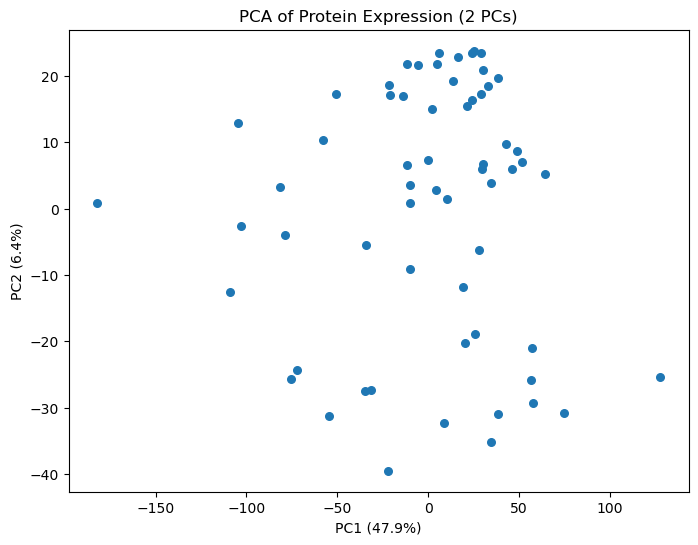

Explained variance ratio (first 10 PCs): [0.47923958 0.06382732]
Total variance explained by 2 PCs: 0.5430668966515177


In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

expr_avg_noNA2 = expr_avg_noNA.drop(columns="Gene")

# Transpose: samples x proteins

X = expr_avg_noNA2.T
X.columns = X.columns.astype(str)

# Initialize PCA
pca = PCA(n_components=2, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2"])

# Quick scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=30)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Protein Expression (2 PCs)")
plt.show()

# Optional: variance explained by first few PCs
print("Explained variance ratio (first 10 PCs):", pca.explained_variance_ratio_[:10])
print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_[:2].sum())

In [25]:
X


Protein_ID,GLYG,AL1L2,FUBP3,SNX12,ARGAL,SBP1,AEBP1,EHD1,DYHC1,TBB3,...,NUDT7,ENC1,DC2I2,CLK2,ZBT45,BUB1,OZF,FLVC1,LCAT,CASQ1
B67_1,13.100614,15.434430,15.008943,14.460709,13.464356,16.756513,18.804153,15.085202,18.082196,19.584024,...,7.522925,5.143371,6.637113,6.852530,6.865707,7.077453,6.410159,8.059024,8.395688,9.893233
CRC0_2,12.767979,8.806588,16.100970,15.553588,14.466067,17.519325,16.024611,15.512185,19.375769,20.685691,...,7.585237,7.412403,7.226273,6.674221,7.742651,7.912519,8.319714,7.615009,5.579209,10.224092
CRC4_P1,9.576825,6.711329,14.789386,13.926841,13.234155,16.805985,14.402964,13.603885,17.870929,19.355991,...,5.922878,6.661093,7.703726,6.287157,5.707670,6.546514,6.419634,8.204672,6.785548,7.999307
G119_P4,11.517666,10.518196,15.256552,14.423072,11.579878,16.609854,15.140057,14.951906,18.905844,19.911063,...,6.196763,5.342908,6.159151,6.933864,6.165565,6.493180,6.499910,7.716249,5.750244,9.149346
G133_P3,15.878984,8.950256,16.741519,15.718494,14.457401,17.722597,12.330405,15.797765,20.743208,21.082307,...,7.469962,7.320269,7.838037,6.979864,6.344302,8.286172,8.307929,7.633937,9.036929,10.845729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VCU_87,13.934935,10.642508,17.531916,15.581943,13.843868,17.216868,16.800971,15.142463,19.627924,21.303055,...,8.124318,6.481046,8.456555,10.069982,7.654527,9.692164,8.887414,7.985134,6.182760,4.471562
VCU_91,15.305525,9.154791,17.317162,15.397135,14.832403,17.659579,17.361142,16.811071,19.901085,20.852336,...,8.487467,5.844353,7.746832,7.332682,8.516145,8.941238,8.422035,7.951810,7.638740,11.318164
VCU_97,13.978164,9.124090,15.673352,15.272916,11.677818,14.171527,17.860677,16.083508,19.130101,20.660837,...,7.824591,5.738469,6.308035,7.781245,7.147279,7.585932,6.297079,7.505613,7.317683,11.729997
VCU_98,14.302432,10.807211,17.392367,15.569471,14.734531,16.328946,14.248528,15.127145,19.840843,20.934593,...,9.708804,7.162462,8.562356,6.880004,7.882419,11.318032,9.233110,8.728123,6.467499,12.377636


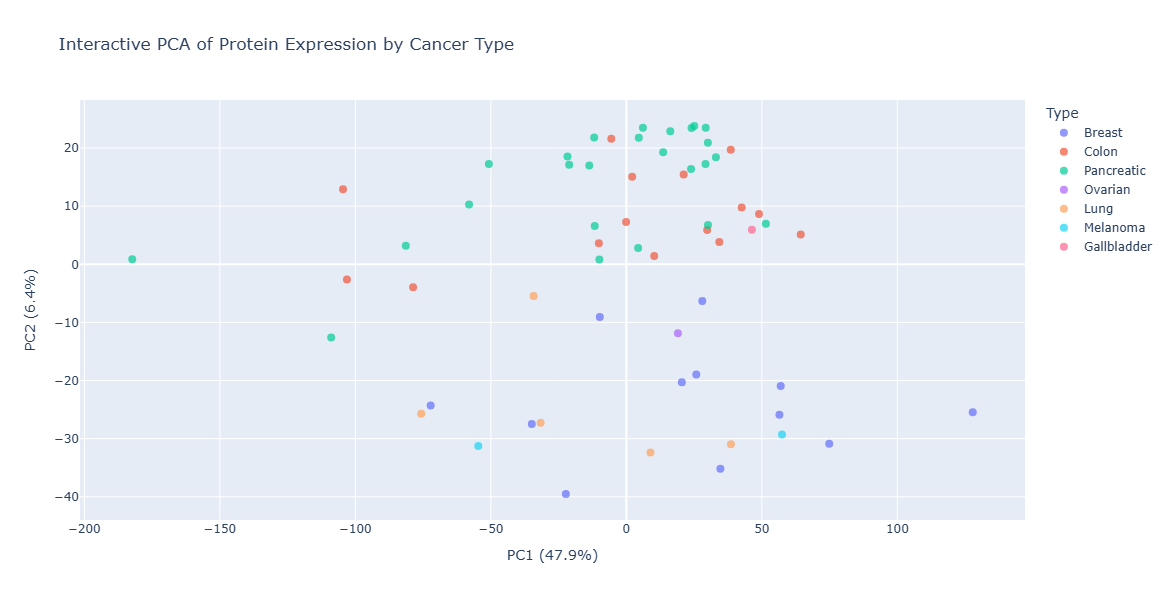

In [35]:
import plotly.express as px

# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

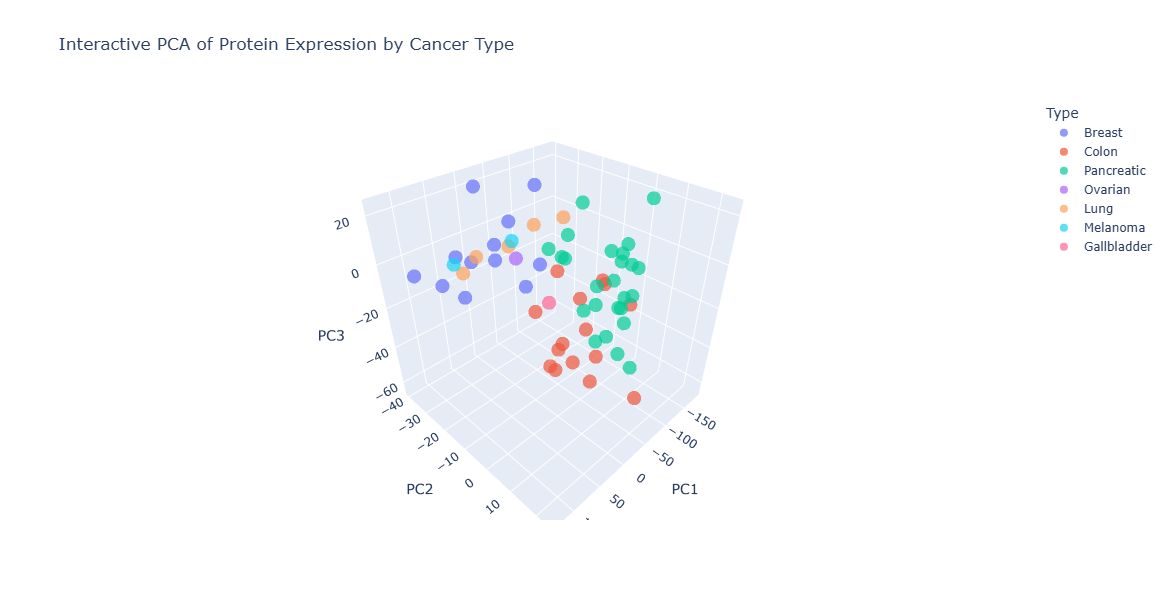

In [36]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter_3d(
    pca_df_merged,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

In [42]:
expr_avg_filt = expr_avg_noNA2.drop(columns="VCU_64")
expr_avg_filt1 = expr_avg_filt.drop(columns="VCU_2")

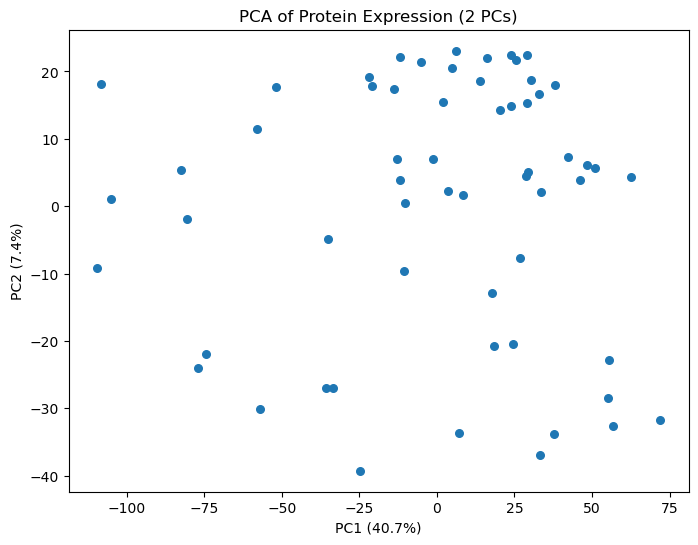

Explained variance ratio (first 10 PCs): [0.40693791 0.07435291 0.05991807]
Total variance explained by 2 PCs: 0.48129082862271955


In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: samples x proteins

X = expr_avg_filt1.T
X.columns = X.columns.astype(str)

# Initialize PCA
pca = PCA(n_components=3, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3"])

# Quick scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=30)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Protein Expression (2 PCs)")
plt.show()

# Optional: variance explained by first few PCs
print("Explained variance ratio (first 10 PCs):", pca.explained_variance_ratio_[:10])
print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_[:2].sum())

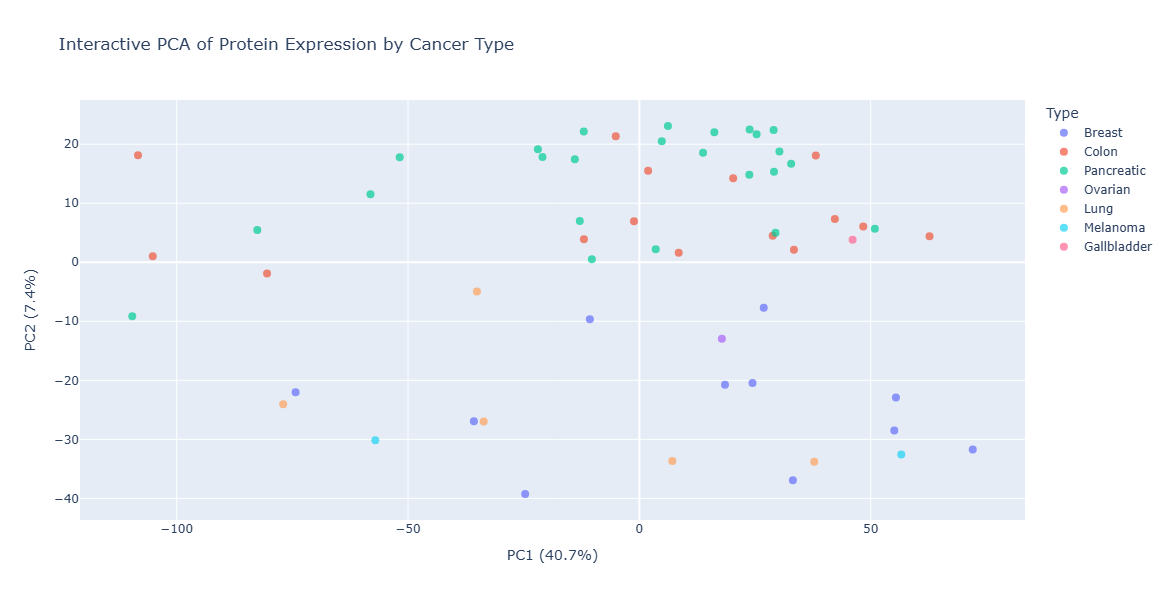

In [44]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

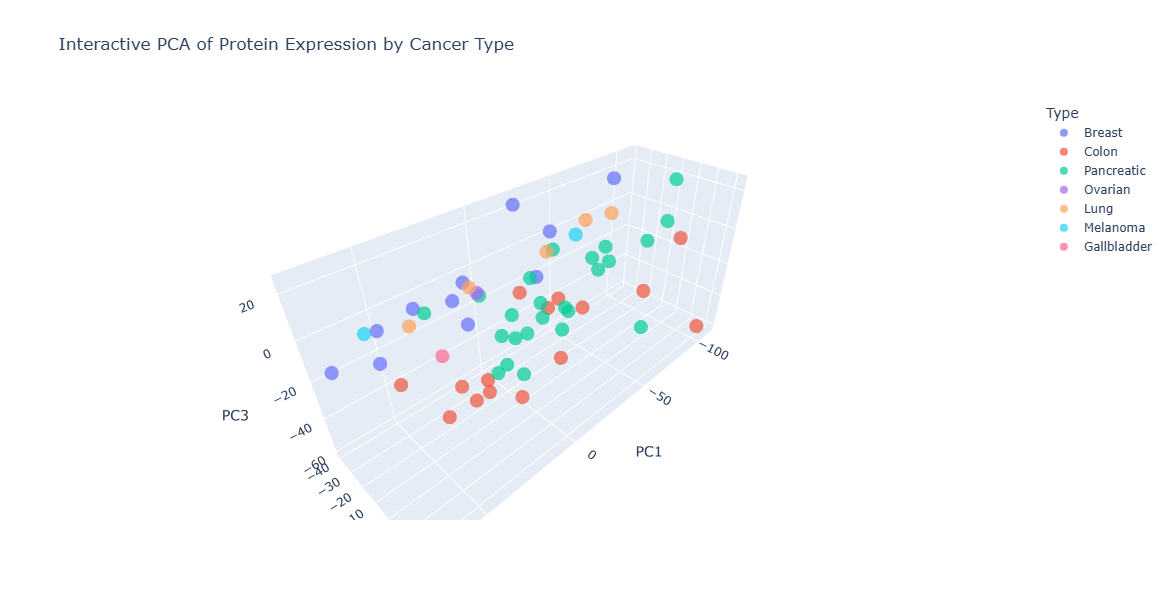

In [45]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter_3d(
    pca_df_merged,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

In [17]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
B67_1,6.061298,-70.411374,11.205389,41.580765,-36.391947,1.285140,5.922948,1.566513,-0.134196,18.451447,-15.983765,19.683350,-14.473451,-2.648230,-2.066925,-6.739958,2.022754,-21.840491,20.293620,2.569580
CRC0_2,38.493508,23.076688,20.596759,-2.437789,-13.998059,11.290064,10.946178,25.787099,-2.001684,-19.926072,1.279413,-3.974596,4.844499,-5.014135,9.056754,5.510039,-3.682429,3.044705,1.454181,-8.752517
CRC4_P1,37.107066,1.984686,-9.699565,56.955320,8.215369,0.541533,14.741724,-1.326381,4.699795,-6.372955,-4.078266,1.034851,4.606357,-12.838173,-5.252183,-31.057130,-1.514976,-8.055471,-7.343660,-9.624832
G119_P4,47.378474,-14.638419,-0.476851,-14.323712,-2.512728,14.163911,-8.445506,27.523166,4.375428,4.678010,-11.166839,-8.300452,6.932926,11.592397,-2.794436,-13.206928,-5.583588,-1.600764,-0.754044,-15.235241
G186_P2,44.015210,-4.714769,21.290509,9.827979,-1.699672,8.609838,23.400893,21.910247,-8.606858,-27.359027,9.648192,-4.741810,2.045831,-5.436111,-3.032286,-0.287428,-1.013819,2.210950,4.048517,-19.000861
G68_P3,45.004457,-60.287563,-11.141275,4.891740,31.589447,5.711531,24.844331,-17.535737,8.237671,-25.853053,8.154123,7.598917,6.015822,17.774690,-9.334068,-8.724402,-5.600831,-5.287789,-0.197857,-23.278122
H107_P1,1.345067,49.988236,10.556393,14.619510,-8.081393,-24.000806,8.550381,4.912035,-10.919876,11.199971,-16.254872,-6.269851,0.428360,13.089701,4.051702,-7.328152,-12.128324,7.106436,3.544200,-0.947651
H30_2,-37.130214,-7.873034,16.246837,9.289817,-18.739812,8.716645,-28.233840,15.439000,23.758551,8.035468,-4.256306,26.157417,59.220369,6.304817,-5.904773,32.941884,-22.784202,8.926661,21.387162,-5.593655
H32_2,-2.890007,59.420795,-32.538131,-0.852470,1.047278,-16.854348,8.464507,2.869140,7.290791,12.538143,-15.513554,-15.582416,21.389101,-0.969463,-1.853368,2.829914,-10.573260,-21.569798,-26.239976,-15.408799
H36,25.812244,-31.716207,-21.174996,25.982194,-50.453405,-27.107851,7.274847,-0.020082,5.687156,-5.174978,-33.205267,3.204359,-8.514572,-2.529817,-12.425814,4.062754,17.014206,-7.707636,-0.062863,0.576313


In [18]:
import pandas as pd
import numpy as np

# Each column in expr_avg is a sample, each row is a protein
loadings = pd.DataFrame(
    pca.components_.T,                      # transpose: proteins × PCs
    index=expr_avg.index,                   # protein IDs
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
Protein_ID,,,,,,,,,,,,,,,,,,,,
PICAL,0.002288,0.000170,0.011664,-0.000553,-0.008220,-0.002096,-0.002604,-0.002538,0.017197,0.004512,0.000345,0.007371,-0.012445,-0.000765,-0.000939,-0.008714,-0.003778,0.004223,0.005854,0.003824
OTUB1,-0.001109,0.001580,0.002723,-0.010450,0.003083,-0.010820,-0.001745,0.005728,-0.000795,0.004705,0.004305,0.001947,0.001464,0.005835,-0.006176,0.009919,0.004386,0.000510,0.005446,-0.002458
BLVRB,0.011969,0.012314,0.010817,-0.011061,-0.010672,0.015974,0.006614,0.002619,0.009139,0.016201,0.014153,-0.015251,-0.001725,0.014115,-0.001597,-0.010652,0.003873,-0.014041,0.001972,0.004540
LRP1,0.006396,-0.009632,-0.004193,0.023951,-0.043607,-0.015713,-0.009967,0.012176,0.027660,-0.020014,-0.012884,-0.001336,0.014550,0.001255,0.023278,0.013054,0.001204,0.012969,-0.001514,-0.008521
DYHC1,-0.001816,-0.000928,0.007885,-0.004736,-0.005799,-0.001703,0.003054,0.002684,0.010084,-0.002924,0.008334,-0.009422,0.001118,0.003125,-0.008574,-0.003498,-0.000315,-0.006051,-0.003397,-0.004941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RPP21,-0.000974,0.000214,-0.001040,-0.005829,0.004160,0.009841,0.012518,-0.009087,-0.005216,0.002906,0.005227,0.009201,-0.012951,-0.007483,0.005450,0.008346,0.009079,-0.005386,0.008928,0.005373
NUFP1,-0.012133,0.012016,-0.001839,-0.007668,0.004231,-0.011021,-0.005079,-0.002921,0.011686,-0.006434,-0.005217,-0.007344,-0.001868,-0.010040,-0.015828,-0.003615,0.008297,-0.003945,0.015330,-0.015822
MMS22,-0.020267,0.001885,-0.001496,0.003231,0.001324,0.004967,0.015334,-0.001205,0.002377,-0.005514,0.014007,0.009533,-0.012314,0.001759,0.009082,-0.028953,0.018032,0.008780,0.006859,0.001200


In [19]:
# Top 20 (by absolute contribution)
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(20)
top_pc1_df = loadings.loc[top_pc1.index, ["PC1"]]
top_pc1_df
top_pc1_df = top_pc1_df.merge(
    metadata,
    left_index=True,
    right_index=True,
    how="left"
)
top_pc1_df.to_csv("Nina_FPA_maxNorm_Unsupervised_PC1_Loadings.tsv", sep="\t", index=False)
top_pc1_df


,PC1,Gene,Protein_ID
Protein_ID,,,
MUC5A,0.063007,MUC5AC,MUC5A
AGR2,0.060078,AGR2,AGR2
AGR3,0.056458,AGR3,AGR3
LEG4,0.055330,NaN,LEG4
PIGR,0.052057,PIGR,PIGR
UCHL1,-0.050012,UCHL1,UCHL1
AK1BA,0.047735,AKR1B10,AK1BA
AIF1L,-0.043875,AIF1L,AIF1L
S100P,0.043833,S100P,S100P


In [20]:
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(20)
top_pc2_df = loadings.loc[top_pc2.index, ["PC2"]]
top_pc2_df
top_pc2_df = top_pc2_df.merge(
    metadata,
    left_index=True,
    right_index=True,
    how="left"
)
top_pc2_df.to_csv("Nina_FPA_maxNorm_Unsupervised_PC2_Loadings.tsv", sep="\t", index=False)
top_pc2_df

,PC2,Gene,Protein_ID
Protein_ID,,,
LEG4,0.080360,NaN,LEG4
CAD17,0.071431,NaN,CAD17
FABPL,0.071248,NaN,FABPL
VILI,0.065555,NaN,VILI
HMCS2,0.065384,NaN,HMCS2
UCHL1,-0.063586,UCHL1,UCHL1
AVIL,0.057714,AVIL,AVIL
MUC5A,0.055746,MUC5AC,MUC5A
TENA,-0.055504,TNC,TENA


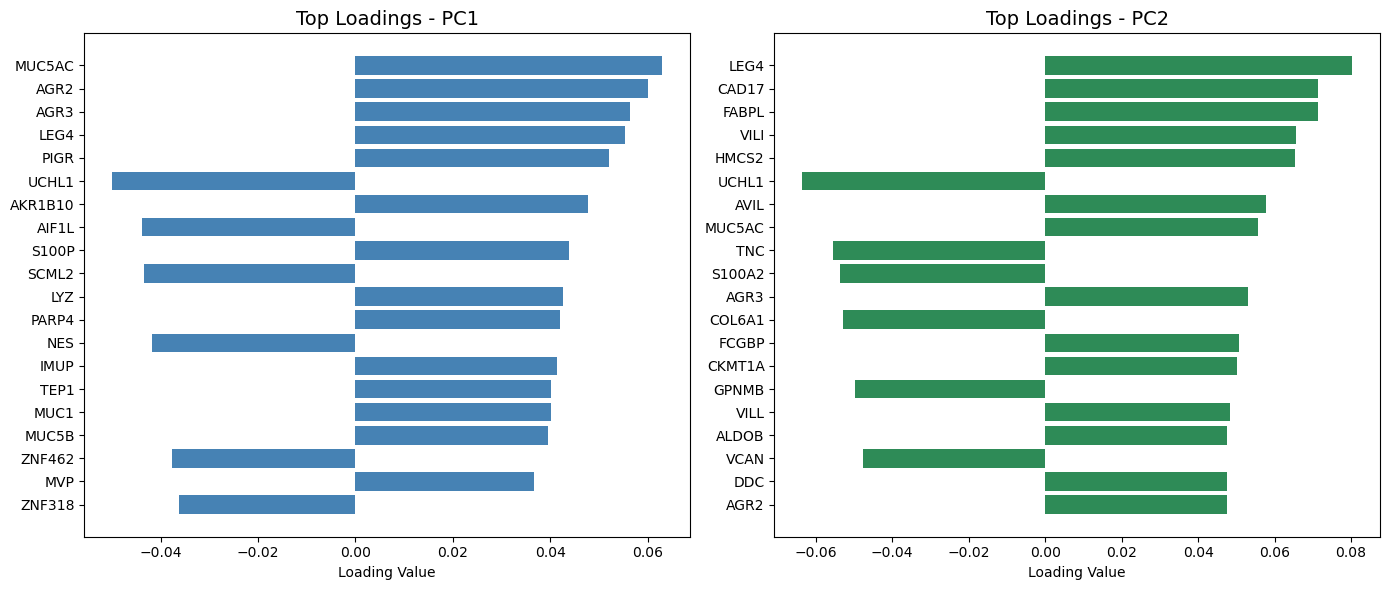

In [21]:
# --- Step 5: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# PC1 Barplot
axes[0].barh(top_pc1_df["Gene"].fillna(top_pc1_df["Protein_ID"]),
             top_pc1_df["PC1"], color="steelblue")
axes[0].set_title("Top Loadings - PC1", fontsize=14)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading Value")

# PC2 Barplot
axes[1].barh(top_pc2_df["Gene"].fillna(top_pc2_df["Protein_ID"]),
             top_pc2_df["PC2"], color="seagreen")
axes[1].set_title("Top Loadings - PC2", fontsize=14)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading Value")

plt.tight_layout()
plt.savefig("PCA_Loadings_PC1_PC2.png", dpi=300, bbox_inches="tight")   # PNG (high-res)
plt.savefig("PCA_Loadings_PC1_PC2.pdf", bbox_inches="tight") 
plt.show()

In [46]:
df_pca_md["Type"].value_counts()

Type
Pancreatic     25
Colon          15
Breast         12
Lung            5
Melanoma        2
Ovarian         1
Gallbladder     1
Name: count, dtype: int64

In [47]:
type_counts = df_pca_md["Type"].value_counts()
print("Sample counts per cancer type:")
print(type_counts)

# Step 2: Identify which types have fewer than 15 samples
types_to_drop = type_counts[type_counts < 5].index
print("\nCancer types to drop (fewer than 5 samples):")
print(types_to_drop.tolist())

# Step 3: Filter metadata to keep only samples with sufficient counts
metadata_filtered = df_pca_md[~df_pca_md["Type"].isin(types_to_drop)]
metadata_filtered

Sample counts per cancer type:
Type
Pancreatic     25
Colon          15
Breast         12
Lung            5
Melanoma        2
Ovarian         1
Gallbladder     1
Name: count, dtype: int64

Cancer types to drop (fewer than 5 samples):
['Melanoma', 'Ovarian', 'Gallbladder']


,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
9,H32_2,Colon
10,H36,Colon


In [49]:
expr_filtered = expr_avg_noNA[metadata_filtered["Sample_ID"].values]
expr_filtered

,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H32_2,H36,...,VCU_80,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
UBA6,15.328913,16.652079,15.585790,16.530554,17.994656,16.109197,16.395952,17.524945,17.998980,17.863580,...,17.526191,17.388412,17.183264,16.881685,17.232664,16.324081,17.567927,17.848873,17.242234,17.522511
ESYT2,14.536260,14.100621,13.382707,13.360824,16.041524,13.870416,12.970300,14.935475,14.447043,15.511956,...,15.703636,15.836865,15.533469,15.305033,15.730956,14.820604,15.048929,13.988184,15.343177,15.352337
BLT3B,10.371815,12.861769,8.304255,9.773264,13.662030,11.185762,9.673950,12.578296,12.048991,12.178630,...,11.957173,10.381483,12.071486,12.276186,11.513950,12.402698,11.221149,12.034151,11.573213,12.016078
SHOT1,11.562930,12.436341,11.199949,11.474999,14.564943,11.995953,10.629103,12.960755,13.490867,12.362946,...,13.993305,11.979409,12.554743,12.052960,10.997221,11.806186,13.494553,10.872854,13.493862,12.937465
HACL2,13.734120,14.756771,14.174855,13.643529,14.899253,14.606481,12.375437,14.725772,13.758987,14.366183,...,14.611247,14.499935,15.632122,15.267077,15.591191,14.795717,15.133712,11.446072,13.812744,15.116516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISOC1,13.722828,16.020169,14.326006,14.426515,16.707490,15.607831,14.635596,16.009428,15.563774,15.577915,...,16.269949,15.195410,16.541336,16.078558,14.426204,16.133305,16.379140,13.967454,16.690102,16.121241
IFG15,13.751347,15.231218,13.576145,13.561182,14.965120,14.231591,13.592718,14.964734,15.046502,14.499584,...,15.048290,14.162080,15.153421,14.600544,14.721188,14.478956,15.622691,13.956622,15.215088,15.314656
ABRAL,11.644731,12.873873,13.059701,11.673027,14.124477,12.722338,12.985758,14.528277,14.345864,13.370446,...,12.710499,12.643563,12.412801,12.698187,12.626160,13.357021,13.069825,13.024110,13.304412,13.903237


In [50]:
expr_avg_filt = expr_filtered.drop(columns="VCU_64")
expr_avg_filt1 = expr_avg_filt.drop(columns="VCU_2")
expr_avg_filt1

,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H32_2,H36,...,VCU_80,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
UBA6,15.328913,16.652079,15.585790,16.530554,17.994656,16.109197,16.395952,17.524945,17.998980,17.863580,...,17.526191,17.388412,17.183264,16.881685,17.232664,16.324081,17.567927,17.848873,17.242234,17.522511
ESYT2,14.536260,14.100621,13.382707,13.360824,16.041524,13.870416,12.970300,14.935475,14.447043,15.511956,...,15.703636,15.836865,15.533469,15.305033,15.730956,14.820604,15.048929,13.988184,15.343177,15.352337
BLT3B,10.371815,12.861769,8.304255,9.773264,13.662030,11.185762,9.673950,12.578296,12.048991,12.178630,...,11.957173,10.381483,12.071486,12.276186,11.513950,12.402698,11.221149,12.034151,11.573213,12.016078
SHOT1,11.562930,12.436341,11.199949,11.474999,14.564943,11.995953,10.629103,12.960755,13.490867,12.362946,...,13.993305,11.979409,12.554743,12.052960,10.997221,11.806186,13.494553,10.872854,13.493862,12.937465
HACL2,13.734120,14.756771,14.174855,13.643529,14.899253,14.606481,12.375437,14.725772,13.758987,14.366183,...,14.611247,14.499935,15.632122,15.267077,15.591191,14.795717,15.133712,11.446072,13.812744,15.116516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISOC1,13.722828,16.020169,14.326006,14.426515,16.707490,15.607831,14.635596,16.009428,15.563774,15.577915,...,16.269949,15.195410,16.541336,16.078558,14.426204,16.133305,16.379140,13.967454,16.690102,16.121241
IFG15,13.751347,15.231218,13.576145,13.561182,14.965120,14.231591,13.592718,14.964734,15.046502,14.499584,...,15.048290,14.162080,15.153421,14.600544,14.721188,14.478956,15.622691,13.956622,15.215088,15.314656
ABRAL,11.644731,12.873873,13.059701,11.673027,14.124477,12.722338,12.985758,14.528277,14.345864,13.370446,...,12.710499,12.643563,12.412801,12.698187,12.626160,13.357021,13.069825,13.024110,13.304412,13.903237


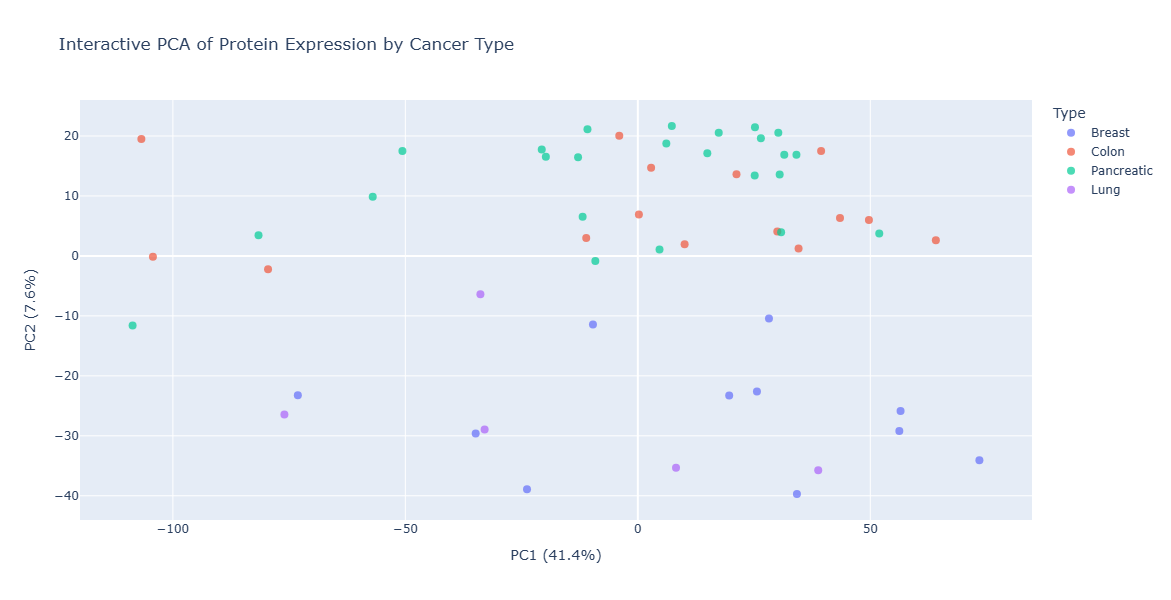

In [51]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X = expr_avg_filt1.T
X.columns = X.columns.astype(str)
X_pca = pca.fit_transform(X)


# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

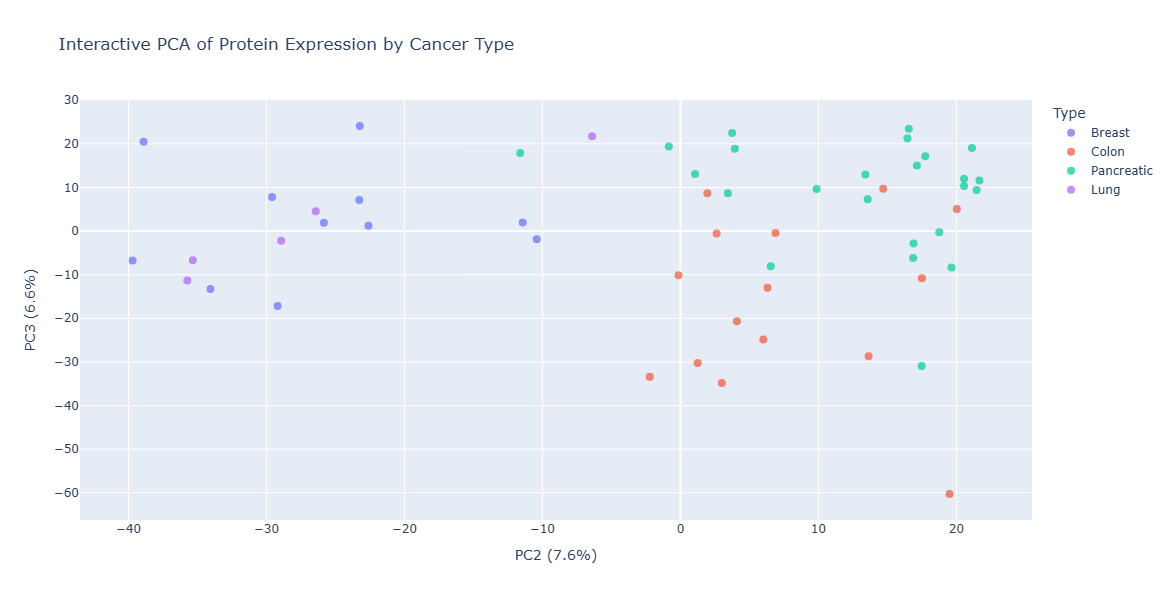

In [65]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X = expr_avg_filt1.T
X.columns = X.columns.astype(str)
X_pca = pca.fit_transform(X)


# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC2",
    y="PC3",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
    yaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
)

fig.show()
#fig.write_html("PCA_Interactive_MP2_E_Resistance_MaxSumNormalized_PC1_PC2.html")

In [59]:
metadata_filtered

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
9,H32_2,Colon
10,H36,Colon


In [62]:
metadata_avg = metadata_filtered[['Sample_ID', 'Type']].drop_duplicates().reset_index(drop=True)
metadata_avg
print(len(metadata_avg))

57


In [63]:
metadata_avg1 = metadata_avg[metadata_avg['Sample_ID'] != 'VCU_64']
metadata_avg2 = metadata_avg1[metadata_avg1['Sample_ID'] != 'VCU_2']
metadata_avg2

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
8,H32_2,Colon
9,H36,Colon


In [70]:
# Set metadata index to match expression matrix
metadata_avg_indexed = metadata_avg2.set_index('Sample_ID').loc[X.index]

# Confirm lengths match
print(len(X), len(metadata_avg2))

metadata_avg_indexed

55 55


,Type
B67_1,Breast
CRC0_2,Colon
CRC4_P1,Colon
G119_P4,Pancreatic
G133_P3,Pancreatic
G186_P2,Pancreatic
G68_P3,Pancreatic
H107_P1,Colon
H32_2,Colon
H36,Colon


In [71]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.cross_decomposition import PLSRegression

# Features: samples x proteins (transpose your imputed expression)
X = expr_avg_filt1.T  # samples x proteins
X.columns = X.columns.astype(str)
# Target: sample types
y = metadata_avg2.set_index('Sample_ID')['Type']

# Encode target as one-hot
lb = LabelBinarizer()
Y_encoded = lb.fit_transform(y)
print("Classes:", lb.classes_)

Classes: ['Breast' 'Colon' 'Lung' 'Pancreatic']


In [72]:
pls = PLSRegression(n_components=3)
pls.fit(X, Y_encoded)

# Project samples into PLS latent space
X_scores = pls.x_scores_


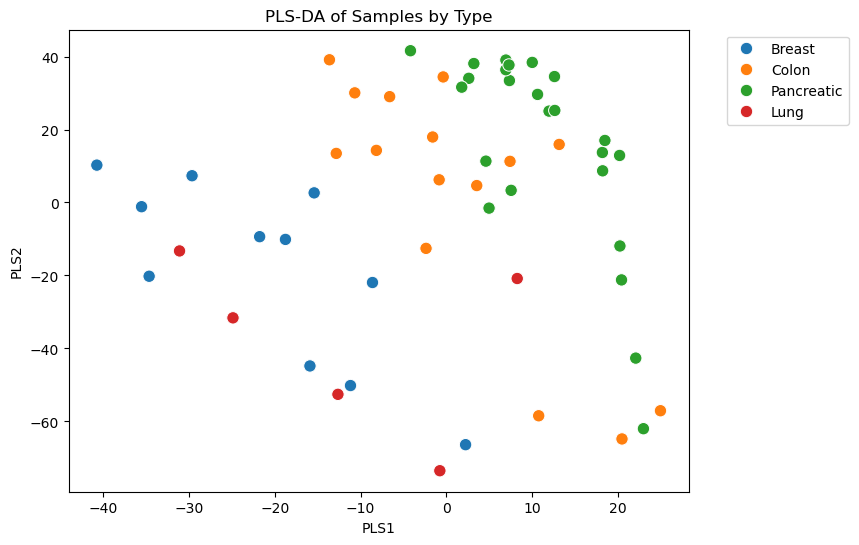

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scores[:,0],
    y=X_scores[:,1],
    hue=y,
    palette='tab10',
    s=80
)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLS-DA of Samples by Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

              PLS1       PLS2       PLS3 Sample_ID        Type
B67_1     2.242550 -66.362379  -9.055445     B67_1      Breast
CRC0_2   13.151812  15.908480   0.281865    CRC0_2       Colon
CRC4_P1  20.472691 -64.790522  15.188935   CRC4_P1       Colon
G119_P4  22.075977 -42.639363  -8.286256   G119_P4  Pancreatic
G133_P3   3.205239  38.077700  -0.293161   G133_P3  Pancreatic


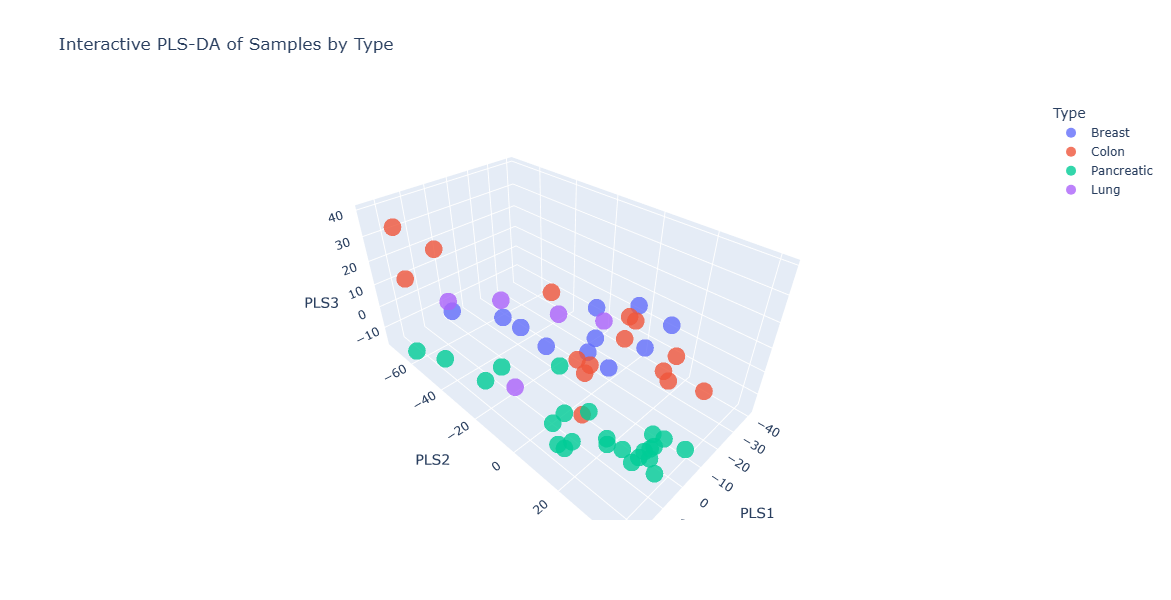

In [74]:
metadata_avg_indexed['Sample_ID'] = metadata_avg_indexed.index

df_scores = pd.DataFrame(
    X_scores,
    columns=['PLS1','PLS2', 'PLS3'],
    index=X.index
)

# Add Sample_ID and Type from metadata
df_scores['Sample_ID'] = metadata_avg_indexed['Sample_ID']
df_scores['Type'] = metadata_avg_indexed['Type']

print(df_scores.head())


import plotly.express as px

fig = px.scatter_3d(
    df_scores,
    x='PLS1',
    y='PLS2',
    z='PLS3',
    color='Type',
    hover_data=['Sample_ID','Type'],
    title='Interactive PLS-DA of Samples by Type',
    width=800,
    height=600
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()
#fig.write_html("PLSDA_3D_Plot_byType_MaxSumNormalized_PC1_PC2_PC3.html")

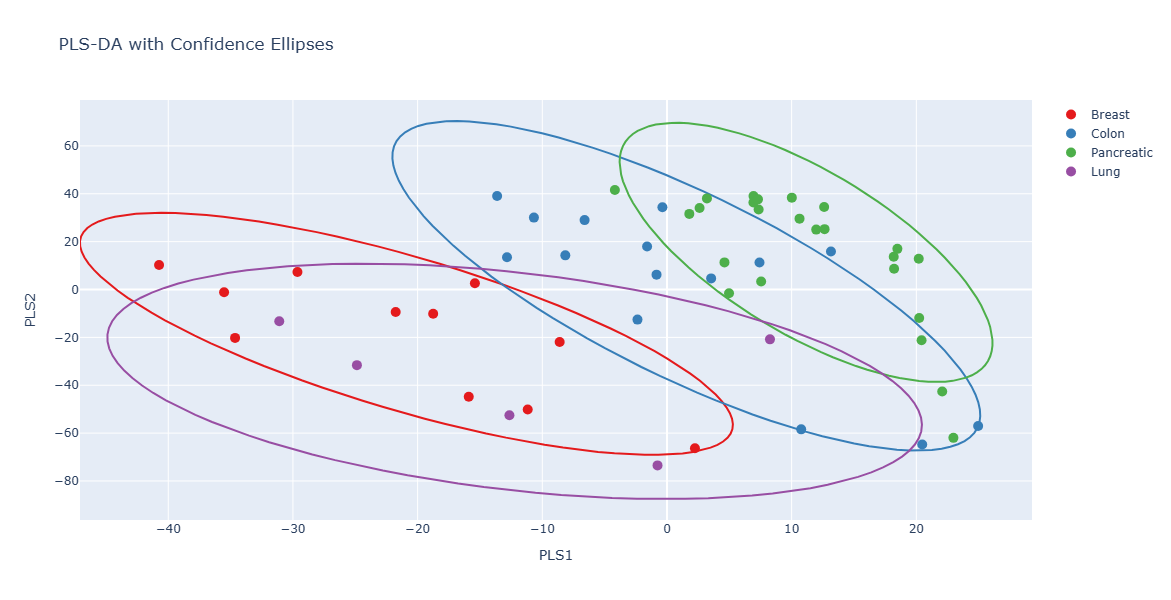

In [76]:
import numpy as np
import plotly.graph_objects as go

def make_ellipse(x, y, n_std=2.0, num_points=100):
    """
    Create an ellipse for the covariance of x and y points.
    n_std = number of standard deviations for the ellipse
    """
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, num_points)
    ellipse = np.array([np.cos(t), np.sin(t)])  # shape 2 x num_points

    # Scale by sqrt(eigenvalues) * n_std
    axes = n_std * np.sqrt(eigvals)
    ellipse = eigvecs @ np.diag(axes) @ ellipse

    # Translate to mean
    ellipse[0, :] += mean_x
    ellipse[1, :] += mean_y

    return ellipse[0, :], ellipse[1, :]

# -------------------------
# Create Plotly figure with points
fig = go.Figure()

types = df_scores['Type'].unique()
colors = px.colors.qualitative.Set1

for i, t in enumerate(types):
    subset = df_scores[df_scores['Type'] == t]
    
    # Add scatter points
    fig.add_trace(go.Scatter(
        x=subset['PLS1'],
        y=subset['PLS2'],
        mode='markers',
        name=t,
        marker=dict(size=10, color=colors[i % len(colors)]),
        hovertext=subset['Sample_ID']
    ))
    
    # Add ellipse
    ex, ey = make_ellipse(subset['PLS1'], subset['PLS2'], n_std=2)
    fig.add_trace(go.Scatter(
        x=ex, y=ey,
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=2),
        name=f"{t} ellipse",
        showlegend=False
    ))

fig.update_layout(
    title="PLS-DA with Confidence Ellipses",
    xaxis_title="PLS1",
    yaxis_title="PLS2",
    width=800,
    height=600
)

fig.show()
#fig.write_html("PLSDA-1-2_Interactive_Breast_Colon_Pancreatic_Lung_MaxSumNorm.html")

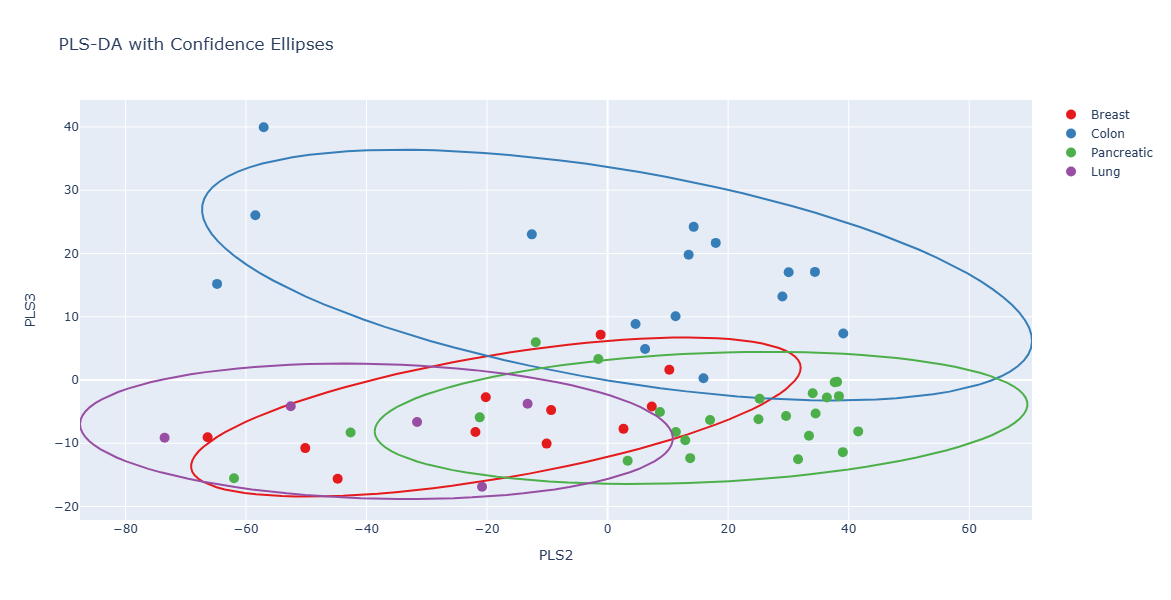

In [79]:
import numpy as np
import plotly.graph_objects as go

def make_ellipse(x, y, n_std=2.0, num_points=100):
    """
    Create an ellipse for the covariance of x and y points.
    n_std = number of standard deviations for the ellipse
    """
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, num_points)
    ellipse = np.array([np.cos(t), np.sin(t)])  # shape 2 x num_points

    # Scale by sqrt(eigenvalues) * n_std
    axes = n_std * np.sqrt(eigvals)
    ellipse = eigvecs @ np.diag(axes) @ ellipse

    # Translate to mean
    ellipse[0, :] += mean_x
    ellipse[1, :] += mean_y

    return ellipse[0, :], ellipse[1, :]

# -------------------------
# Create Plotly figure with points
fig = go.Figure()

types = df_scores['Type'].unique()
colors = px.colors.qualitative.Set1

for i, t in enumerate(types):
    subset = df_scores[df_scores['Type'] == t]
    
    # Add scatter points
    fig.add_trace(go.Scatter(
        x=subset['PLS2'],
        y=subset['PLS3'],
        mode='markers',
        name=t,
        marker=dict(size=10, color=colors[i % len(colors)]),
        hovertext=subset['Sample_ID']
    ))
    
    # Add ellipse
    ex, ey = make_ellipse(subset['PLS2'], subset['PLS3'], n_std=2)
    fig.add_trace(go.Scatter(
        x=ex, y=ey,
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=2),
        name=f"{t} ellipse",
        showlegend=False
    ))

fig.update_layout(
    title="PLS-DA with Confidence Ellipses",
    xaxis_title="PLS2",
    yaxis_title="PLS3",
    width=800,
    height=600
)

fig.show()
#fig.write_html("PLSDA-1-3_2D_Interactive_Breast_Colon_Pancreatic_Lung_MaxSumNorm_.html")

In [46]:
# -------------------------
# 3️⃣ Extract protein loadings
# These indicate how strongly each protein contributes to the components
loadings = pd.DataFrame(
    pls.x_loadings_,
    index=expr_avg.index,  # Protein_IDs
    columns=[f'PLS{i+1}' for i in range(pls.x_loadings_.shape[1])]
)

# -------------------------
# 4️⃣ Rank proteins by importance
# Use absolute value of loadings (higher = more discriminative)
loadings['max_abs_loading'] = loadings.abs().max(axis=1)
top_proteins = loadings.sort_values('max_abs_loading', ascending=False)

# -------------------------
# 5️⃣ Inspect top proteins
top_n = 100
print(f"Top {top_n} proteins contributing to sample type separation:")
print(top_proteins.head(top_n))

# Optional: write to file
top_proteins.to_csv("PLSDA_top_proteins_Breast_Colon_Pancreatic_Lung.txt", sep='\t')

Top 100 proteins contributing to sample type separation:
                PLS1      PLS2      PLS3  max_abs_loading
Protein_ID                                               
PICK1       0.005384  0.004462  0.041715         0.041715
EST1       -0.005707  0.005582 -0.039635         0.039635
COMD5      -0.004212  0.002574  0.038842         0.038842
FCL         0.013029 -0.002394  0.038230         0.038230
TMF1        0.000720  0.005740  0.037141         0.037141
...              ...       ...       ...              ...
PI4KB      -0.014659 -0.008335  0.031924         0.031924
ZO3         0.011646  0.012787  0.031849         0.031849
CNO11      -0.014997  0.003836  0.031836         0.031836
AGRIN       0.006184 -0.031829 -0.000710         0.031829
L2GL2       0.007421  0.011597  0.031819         0.031819

[100 rows x 4 columns]


In [166]:
metadata

,Gene,Protein_ID
Protein_ID,,
1433B,YWHAB,1433B
1433E,YWHAE,1433E
1433F,YWHAH,1433F
1433G,YWHAG,1433G
1433S,SFN,1433S
...,...,...
ZXDC,ZXDC,ZXDC
ZY11B,ZYG11B,ZY11B
ZYX,ZYX,ZYX


In [72]:
df_pca_md.index.name = 'Index_Sample_ID'
metadata.index.name = 'Index_Protein_ID'

# --- Imports ---
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Colon', 'Pancreatic', 'Lung']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg.index:
    values = [expr_avg.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")


anova_df



,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene
0,GLYG,NaN,NaN,NaN,15764.361111,11606.785714,21668.560000,11100.200000,GYG1
1,AL1L2,NaN,NaN,NaN,18836.111111,3579.848485,2209.566667,13117.750000,ALDH1L2
2,FUBP3,0.808784,0.494645,NaN,119464.805556,101322.555556,89314.026667,99380.133333,FUBP3
3,SNX12,2.352243,0.082600,NaN,52776.888889,35992.600000,40535.280000,30012.933333,SNX12
4,ARGAL,5.061931,0.003714,NaN,22444.444444,27885.133333,13263.466667,1528.133333,ARHGEF10L
...,...,...,...,...,...,...,...,...,...
10831,PCDG6,NaN,NaN,NaN,2810.333333,NaN,NaN,NaN,NaN
10832,FBLN7,NaN,NaN,NaN,185.000000,NaN,NaN,NaN,NaN
10833,IL1B,NaN,NaN,NaN,NaN,NaN,978.500000,1039.333333,NaN
10834,KISS1,NaN,NaN,NaN,NaN,NaN,1561.000000,NaN,NaN


In [70]:
# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)
anova_df

/tmp/ipykernel_2900337/1537391758.py:2: FutureWarning:

The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError

/tmp/ipykernel_2900337/1537391758.py:3: FutureWarning:

The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC
0,GLYG,NaN,NaN,NaN,13.686628,12.695084,13.995170,13.068503,GYG1,Pancreatic,Colon,1.300086
1,AL1L2,NaN,NaN,NaN,12.660510,10.286663,9.426635,12.723279,ALDH1L2,Lung,Pancreatic,3.296644
2,FUBP3,0.490392,0.690446,NaN,16.621730,16.315564,16.203753,16.366743,FUBP3,Breast,Pancreatic,0.417977
3,SNX12,1.709633,0.176159,NaN,15.465517,14.911205,15.218946,14.820514,SNX12,Breast,Lung,0.645002
4,ARGAL,11.764297,0.000005,NaN,13.658159,14.392618,13.070582,9.639780,ARHGEF10L,Colon,Lung,4.752838
...,...,...,...,...,...,...,...,...,...,...,...,...
10831,PCDG6,NaN,NaN,NaN,11.452759,NaN,NaN,NaN,NaN,Breast,Breast,0.000000
10832,FBLN7,NaN,NaN,NaN,7.512992,NaN,NaN,NaN,NaN,Breast,Breast,0.000000
10833,IL1B,NaN,NaN,NaN,NaN,NaN,9.934002,10.017928,NaN,Lung,Pancreatic,0.083926
10834,KISS1,NaN,NaN,NaN,NaN,NaN,10.584541,NaN,NaN,Pancreatic,Pancreatic,0.000000


In [49]:
# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nsmallest(top_n, "p_adj")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
top_genes_df = top_genes_df.sort_values("Type")
top_genes_df

,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC,Type
3237,AIF1L,33.974799,3.287432e-12,1.700479e-09,15.126688,10.593138,10.096591,11.602085,AIF1L,Breast,Pancreatic,5.030097,Breast
3534,TRPS1,26.688229,1.611729e-10,4.899859e-08,18.150665,12.957038,12.910008,14.564656,TRPS1,Breast,Pancreatic,5.240657,Breast
3756,HOME3,26.170933,2.175904e-10,6.029585e-08,14.650407,10.970057,11.558198,14.102054,HOMER3,Breast,Colon,3.680351,Breast
1027,RABP2,24.654856,5.353870e-10,1.258808e-07,19.664249,13.222823,16.691357,16.065588,CRABP2,Breast,Colon,6.441425,Breast
1770,RABE1,23.040764,1.447410e-09,2.739135e-07,16.676698,15.082727,14.171081,15.282713,RABEP1,Breast,Pancreatic,2.505617,Breast
5669,FOXC1,22.914045,1.567537e-09,2.834702e-07,13.008377,10.658846,9.894974,10.159371,FOXC1,Breast,Pancreatic,3.113403,Breast
5164,MAGD1,22.804201,1.680042e-09,2.962601e-07,14.186900,11.125937,10.289872,12.511348,MAGED1,Breast,Pancreatic,3.897028,Breast
5335,SETMR,19.874652,1.146967e-08,1.328256e-06,14.476970,13.872226,11.500737,13.067194,SETMAR,Breast,Pancreatic,2.976233,Breast
2291,SRGP2,19.684372,1.306004e-08,1.427224e-06,15.066153,12.086741,13.203665,13.997084,SRGAP2,Breast,Colon,2.979412,Breast
4447,DVL2,19.684581,1.305818e-08,1.427224e-06,14.982648,12.718233,12.757921,14.802902,DVL2,Breast,Colon,2.264414,Breast


/tmp/ipykernel_1511351/1763873098.py:144: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



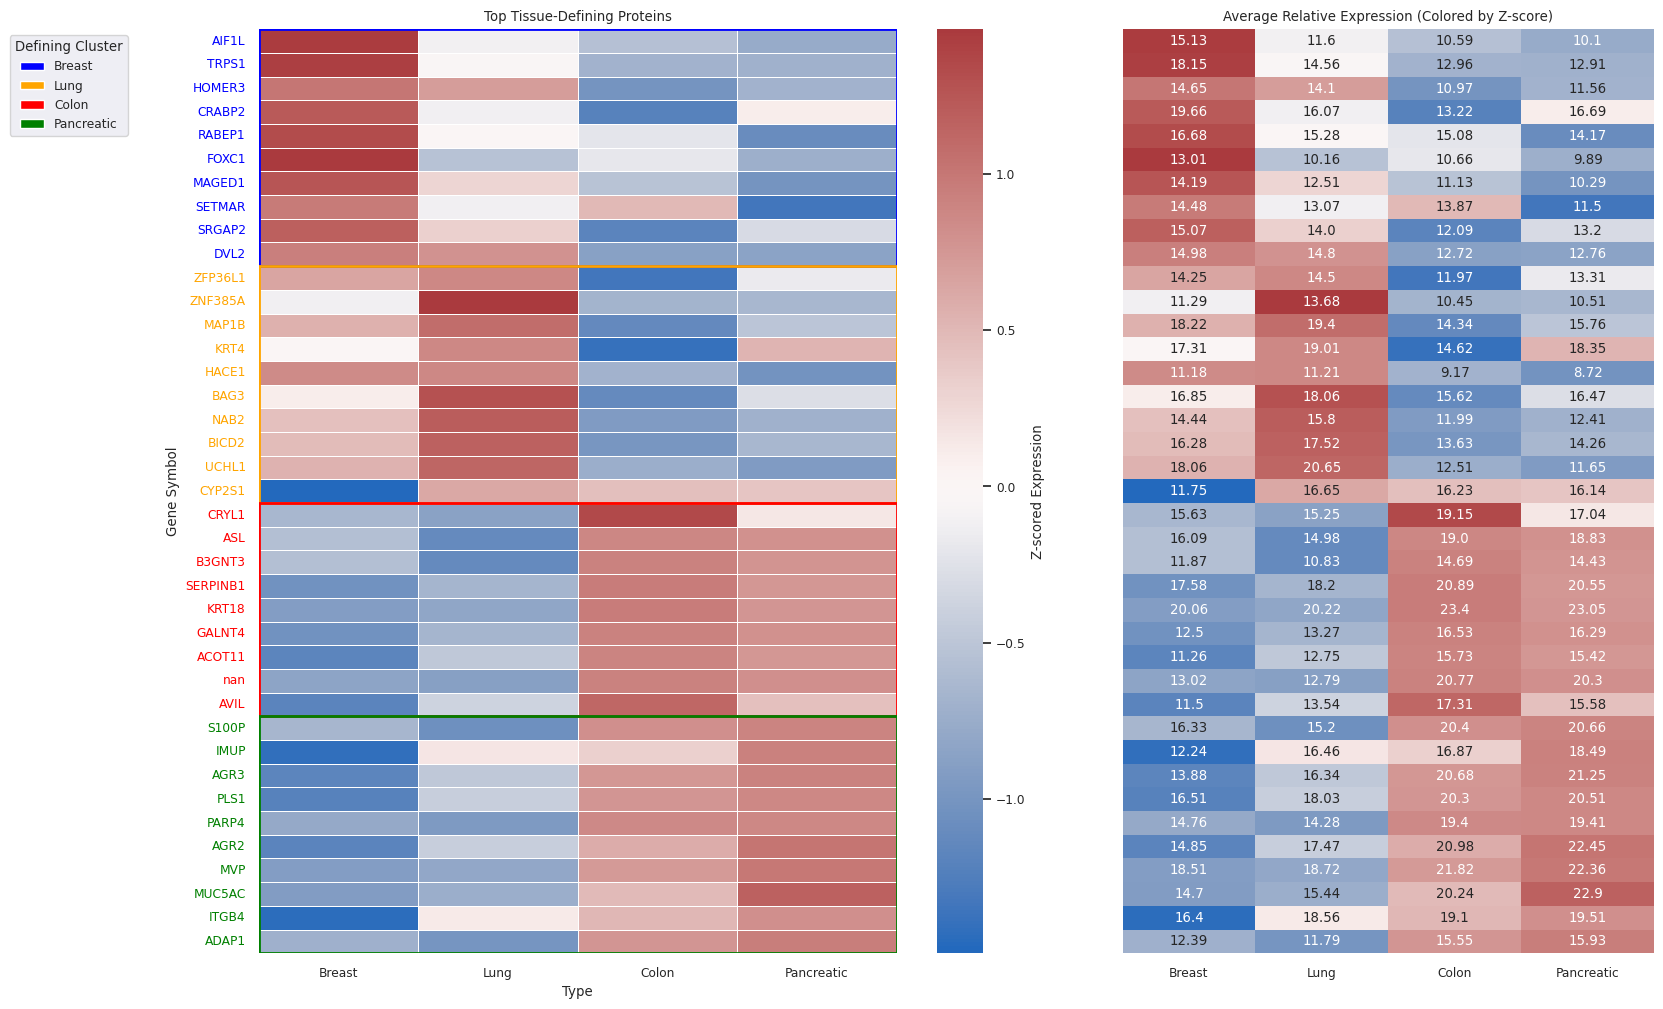

In [50]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Lung', 'Colon', 'Pancreatic']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg_filt[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg_filt.index:
    values = [expr_avg_filt.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")

# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)

# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nsmallest(top_n, "p_adj")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']
top_genes_df['Type'] = pd.Categorical(top_genes_df['Type'], categories=type_order, ordered=True)
top_genes_df = top_genes_df.sort_values('Type')

top_genes_df

# --- Step 8. Build heatmap data ---
heatmap_data = cluster_means.loc[top_genes_df["Protein_ID"], ['Breast', 'Lung', 'Colon', 'Pancreatic']]
heatmap_data.index = top_genes_df["Gene"]

# --- Step 9. Compute Z-scores across all clusters ---
heatmap_data_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

# --- Step 10. Define cluster colors ---
cluster_color_map = {'Breast': "blue", 'Lung': "orange", 'Colon': "red", 'Pancreatic': "green"}
row_colors = top_genes_df.set_index("Gene")["Type"].map(cluster_color_map)

# --- Step 11. Plot heatmap + expression table ---
sns.set(font_scale=0.8)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2], wspace=0.1)

# Left: Z-scored heatmap
ax0 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_z,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Z-scored Expression"},
    ax=ax0,
    yticklabels=True,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic']
)
ax0.set_title("Top Tissue-Defining Proteins")
ax0.set_xlabel("Type")
ax0.set_ylabel("Gene Symbol")

# Color row labels by defining cluster
for ytick, gene in zip(ax0.get_yticklabels(), heatmap_data_z.index):
    cluster = top_genes_df.set_index("Gene").loc[gene, "Type"]
    ytick.set_color(cluster_color_map[cluster])

# --- Fix: Color expression table by Z-scores but show average values ---
# We re-use the color mapping from heatmap_data_z for coloring
ax1 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_z,       # use Z-scores for coloring
    annot=heatmap_data.round(2),  # show actual average expression values
    fmt="",               # suppress scientific notation
    cmap="vlag",
    center=0,
    cbar=False,
    yticklabels=False,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic'],
    ax=ax1
)
ax1.set_title("Average Relative Expression (Colored by Z-score)")
ax1.set_ylabel("")

# --- Step 12. Legend for defining clusters ---
handles = [Patch(facecolor=color, label=c) for c, color in cluster_color_map.items()]
ax0.legend(handles=handles, title="Defining Cluster", loc="upper left", bbox_to_anchor=(-0.4, 1))

# --- Step 13. Bounding boxes for cluster-defining genes (respect ordered tissue list) ---
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']

for cluster in type_order:
    color = cluster_color_map[cluster]
    gene_indices = [
        i for i, gene in enumerate(heatmap_data_z.index)
        if top_genes_df.set_index("Gene").loc[gene, "Type"] == cluster
    ]
    if not gene_indices:
        continue
    y_start = min(gene_indices)
    y_end = max(gene_indices) + 1
    rect = patches.Rectangle(
        xy=(0, y_start),
        width=len(type_order),
        height=y_end - y_start,
        fill=False,
        edgecolor=color,
        linewidth=2
    )
    ax0.add_patch(rect)

plt.tight_layout()
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_padj.png", dpi=300, bbox_inches="tight")
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_padj.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1511351/2769233910.py:144: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



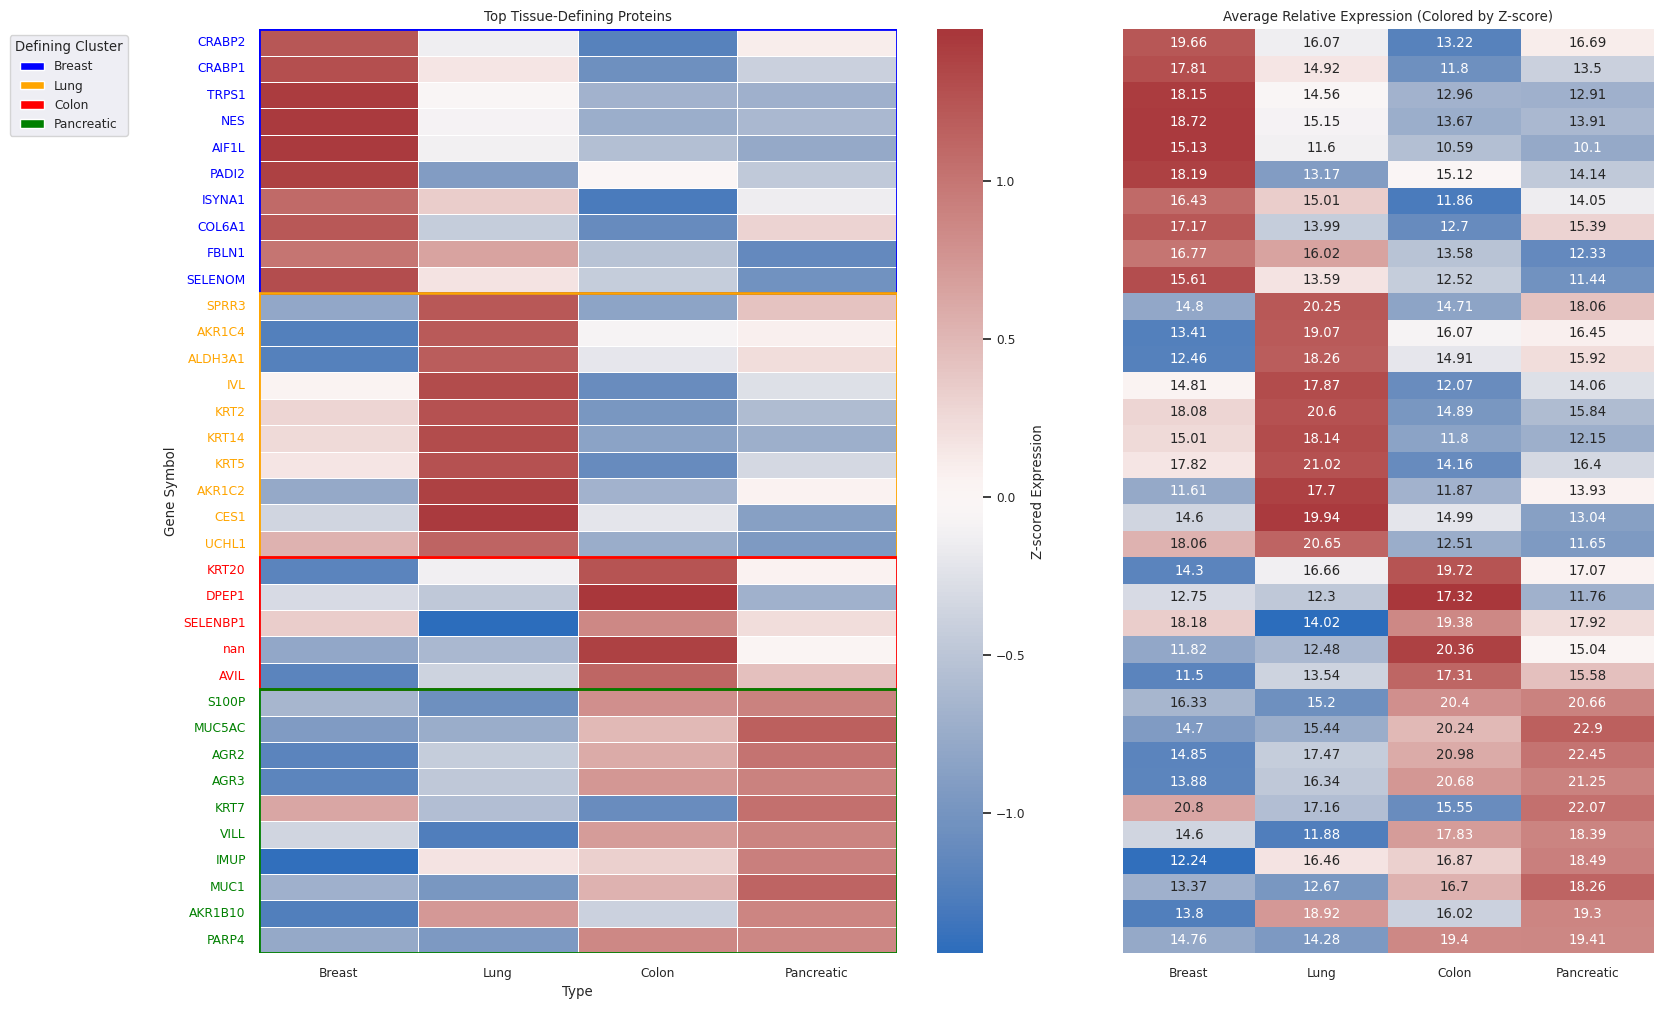

In [52]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Lung', 'Colon', 'Pancreatic']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg_filt[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg_filt.index:
    values = [expr_avg_filt.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")

# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)

# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nlargest(top_n, "Greatest_Log2FC")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']
top_genes_df['Type'] = pd.Categorical(top_genes_df['Type'], categories=type_order, ordered=True)
top_genes_df = top_genes_df.sort_values('Type')

top_genes_df

# --- Step 8. Build heatmap data ---
heatmap_data = cluster_means.loc[top_genes_df["Protein_ID"], ['Breast', 'Lung', 'Colon', 'Pancreatic']]
heatmap_data.index = top_genes_df["Gene"]

# --- Step 9. Compute Z-scores across all clusters ---
heatmap_data_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

# --- Step 10. Define cluster colors ---
cluster_color_map = {'Breast': "blue", 'Lung': "orange", 'Colon': "red", 'Pancreatic': "green"}
row_colors = top_genes_df.set_index("Gene")["Type"].map(cluster_color_map)

# --- Step 11. Plot heatmap + expression table ---
sns.set(font_scale=0.8)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2], wspace=0.1)

# Left: Z-scored heatmap
ax0 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_z,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Z-scored Expression"},
    ax=ax0,
    yticklabels=True,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic']
)
ax0.set_title("Top Tissue-Defining Proteins")
ax0.set_xlabel("Type")
ax0.set_ylabel("Gene Symbol")

# Color row labels by defining cluster
for ytick, gene in zip(ax0.get_yticklabels(), heatmap_data_z.index):
    cluster = top_genes_df.set_index("Gene").loc[gene, "Type"]
    ytick.set_color(cluster_color_map[cluster])

# --- Fix: Color expression table by Z-scores but show average values ---
# We re-use the color mapping from heatmap_data_z for coloring
ax1 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_z,       # use Z-scores for coloring
    annot=heatmap_data.round(2),  # show actual average expression values
    fmt="",               # suppress scientific notation
    cmap="vlag",
    center=0,
    cbar=False,
    yticklabels=False,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic'],
    ax=ax1
)
ax1.set_title("Average Relative Expression (Colored by Z-score)")
ax1.set_ylabel("")

# --- Step 12. Legend for defining clusters ---
handles = [Patch(facecolor=color, label=c) for c, color in cluster_color_map.items()]
ax0.legend(handles=handles, title="Defining Cluster", loc="upper left", bbox_to_anchor=(-0.4, 1))

# --- Step 13. Bounding boxes for cluster-defining genes (respect ordered tissue list) ---
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']

for cluster in type_order:
    color = cluster_color_map[cluster]
    gene_indices = [
        i for i, gene in enumerate(heatmap_data_z.index)
        if top_genes_df.set_index("Gene").loc[gene, "Type"] == cluster
    ]
    if not gene_indices:
        continue
    y_start = min(gene_indices)
    y_end = max(gene_indices) + 1
    rect = patches.Rectangle(
        xy=(0, y_start),
        width=len(type_order),
        height=y_end - y_start,
        fill=False,
        edgecolor=color,
        linewidth=2
    )
    ax0.add_patch(rect)

plt.tight_layout()
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_L2FC.png", dpi=300, bbox_inches="tight")
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_L2FC.pdf", bbox_inches="tight")
plt.show()

In [51]:
# --- Step 14. Export ANOVA table ---
anova_df.to_csv("ANOVA_with_FDR_Log2FC_wLung.tsv", sep="\t", index=False)
anova_df

,Protein_ID,F_value,p_value,p_adj,Breast,Lung,Colon,Pancreatic,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC
0,PICAL,1.647023,0.190107,0.279893,17.070167,17.018885,17.011880,17.380580,PICALM,Pancreatic,Colon,0.368700
1,OTUB1,2.678478,0.056701,0.114943,18.462832,19.145287,18.438522,18.680849,OTUB1,Lung,Colon,0.706766
2,BLVRB,4.694210,0.005708,0.021425,18.423432,17.927587,18.995940,19.530646,BLVRB,Pancreatic,Lung,1.603059
3,LRP1,0.359882,0.782207,0.819158,16.253963,16.265908,16.860553,16.284555,LRP1,Colon,Breast,0.606590
4,DYHC1,1.344289,0.270360,0.364315,21.605241,21.560135,21.308915,21.596715,DYNC1H1,Breast,Colon,0.296325
...,...,...,...,...,...,...,...,...,...,...,...,...
7754,RPP21,3.635192,0.018758,0.051629,11.263109,10.330101,10.390663,10.868036,NaN,Breast,Lung,0.933008
7755,NUFP1,1.588024,0.203673,0.295715,10.895452,10.976410,11.044614,10.392431,NaN,Colon,Pancreatic,0.652183
7756,MMS22,5.576816,0.002186,0.010501,11.589476,11.282879,10.504282,10.046004,NaN,Breast,Pancreatic,1.543472
7757,APDD1,0.161185,0.921966,0.934858,9.717684,9.680602,9.566017,9.698238,NaN,Breast,Colon,0.151667


In [103]:
anova_df

,PG.ProteinGroups,F_value,p_value,p_adj,Cluster_0,Cluster_1,Cluster_2,Cluster_3,PG.Genes,Highest_Cluster,Highest_Cluster_Num,log2FC_vs_Control
0,A0A096LP01,17.869608,3.325111e-07,0.000003,11.452787,11.123440,10.196192,10.495332,SMIM26,Cluster_0,0,0.000000
1,A0A0B4J2D5;P0DPI2,8.597950,2.068880e-04,0.000605,15.370686,15.471430,15.553899,16.934887,GATD3B;GATD3,Cluster_3,3,1.564202
2,A0A0U1RRL7,3.665975,2.133900e-02,0.031767,14.344706,14.795515,14.432464,15.255677,MMP24OS,Cluster_3,3,0.910971
3,A0A2Z4LIS9,5.542346,3.205095e-03,0.006085,11.409981,11.228513,10.877164,10.885332,FOXO3B,Cluster_0,0,0.000000
4,A0AVF1,2.286891,9.568262e-02,0.118525,10.743602,10.247984,10.295332,10.491830,IFT56,Cluster_0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
6782,Q9Y6X3,19.668866,1.201448e-07,0.000002,12.291902,11.651959,11.284475,11.970797,MAU2,Cluster_0,0,0.000000
6783,Q9Y6X4,8.412845,2.415802e-04,0.000689,10.352023,10.865018,10.772815,12.314873,FAM169A,Cluster_3,3,1.962850
6784,Q9Y6X9,10.313698,5.217796e-05,0.000192,12.880408,12.089604,12.112280,11.983099,MORC2,Cluster_0,0,0.000000
6785,Q9Y6Y0,2.059647,1.233794e-01,0.148392,12.208793,12.387747,12.648415,11.886095,IVNS1ABP,Cluster_2,2,0.439622
